Import JSON Device Recall Data

In [1]:
import pandas as pd
import json
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity



In [2]:
json_path = "/projectnb/sparkgrp/dd4g-muckrock-patient-safety/device-recall-0001-of-0001.json"

# Load JSON
with open(json_path, 'r') as f:
    data = json.load(f)

#print(type(data)) 
#print(list(data.keys())

df = pd.json_normalize(data['results'])
#print("DataFrame shape:", df.shape)
#print("Columns:", df.columns)


In [3]:
df.head()

,cfres_id,product_res_number,event_date_initiated,event_date_posted,recall_status,res_event_number,product_code,product_description,code_info,recalling_firm,...,openfda.regulation_number,openfda.device_class,address_2,event_date_terminated,firm_fei_number,other_submission_description,k_numbers,pma_numbers,event_date_created,openfda.pma_number
0,218307,Z-1472-2026,2026-01-21,2026-02-26,"Open, Classified",98332,FNM,"Adapt Pump, Model/Catalog Number: 61600200-Ada...",UDI-DI 0084569904914; All serial numbers with ...,Agiliti Health Ellis,...,880.5550,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,218406,Z-1462-2026,2026-01-14,2026-02-24,"Open, Classified",98303,KPL,"PIE PAK\nModels: P2HC-A, P2HC-S, P2HC",All Lots\nUDI:,Edermy LLC,...,876.5220,2,Ste A,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,105069,Z-0389-2012,2011-09-19,2012-01-11,Terminated,60344,LFQO,Magnus Hybrid operating table columns 1180.01A...,"510 k EXEMPT 1180.01A1- Lot #0002, 0004, 0005...",Maquet Inc.,...,NaN,NaN,NaN,2011-12-08,NaN,NaN,NaN,NaN,NaN,NaN
3,105700,Z-0485-2012,2011-11-28,2012-01-11,Terminated,60528,RER,Raymond Laser alignment guide - Model #1096597...,Model #1096597/002,The Raymond Corporation S Canal,...,,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,131624,Z-0604-2015,2014-11-17,2014-12-12,Terminated,69838,KOG,"PKG, OBTURATOR, 5.5MM FOR HASSON CANNULA, P/N ...",37302 37858 39543 45622 48347 48903 49147 4914...,Stryker Endoscopy,...,NaN,NaN,NaN,2015-07-17,2936485,NaN,NaN,NaN,NaN,NaN


Identify Unique Product Codes and IDs

In [4]:
print(df['product_code'].unique()[:10])
print(df['cfres_id'].unique()[:10])

['FNM' 'KPL' 'LFQO' 'RER' 'KOG' 'N/A' 'RCE' 'REM' 'RHP' 'MIE']
['218307' '218406' '105069' '105700' '131624' '131797' '131743' '131693'
 '131625' '131848']


Basic EDA (explore how many rows contain issues involving batteries, for instance)

In [5]:
battery_rows = df[df['reason_for_recall'].str.contains("battery", case=False, na=False)]

print(battery_rows.shape)
print(battery_rows.head()) 

(920, 35)
    cfres_id product_res_number event_date_initiated event_date_posted  \
124   181608        Z-0518-2021           2020-04-30               NaN   
143   172735        Z-1773-2019           2019-05-10               NaN   
495   103146        Z-0142-2012           2011-09-23        2011-10-31   
621   112481        Z-0049-2013           2012-09-25        2012-10-11   
862    64398        Z-0051-2008           2007-03-16        2007-11-24   

        recall_status res_event_number product_code  \
124  Open, Classified            85711          N/A   
143        Terminated            82803          LPA   
495        Terminated            59582          DRY   
621        Terminated            63079          KFM   
862        Terminated            44793          LWP   

                                   product_description  \
124  MiniMed 640G, insulin pump, Ref/Model # MMT-17...   
143  CardioCommand, Inc. Transesophageal Cardiac Pa...   
495  CDI Blood Parameter Monitoring Syst

In [6]:
#account for nulls 
df['reason_for_recall'] = df['reason_for_recall'].fillna('')

#how many rows contain batteries
battery_count = df['reason_for_recall'].str.contains('battery', case=False).sum()
print(f"Rows containing 'battery': {battery_count}")

Rows containing 'battery': 920


In [7]:
vectorizer = CountVectorizer(ngram_range=(2,2), stop_words='english')
X = vectorizer.fit_transform(df['reason_for_recall'])

#sum columns directly on sparse matrix
sums = X.sum(axis=0)  
sums_array = sums.A1 

bigrams = Counter(dict(zip(vectorizer.get_feature_names_out(), sums_array)))
print(bigrams.most_common(20))

[('instructions use', np.int64(1165)), ('sterile barrier', np.int64(1099)), ('recall initiated', np.int64(1010)), ('expiration date', np.int64(961)), ('kits contain', np.int64(768)), ('compromising sterility', np.int64(756)), ('package integrity', np.int64(719)), ('shelf life', np.int64(690)), ('non sterile', np.int64(666)), ('use ifu', np.int64(634)), ('specific lots', np.int64(617)), ('received complaints', np.int64(614)), ('convenience kits', np.int64(610)), ('ge healthcare', np.int64(586)), ('firm received', np.int64(573)), ('lot number', np.int64(525)), ('received reports', np.int64(513)), ('ethylene oxide', np.int64(492)), ('voluntary recall', np.int64(470)), ('product sterility', np.int64(466))]


Import FDA Problem Codes Dataset

In [8]:
foi_file = "/projectnb/sparkgrp/dd4g-muckrock-patient-safety/foiclass.txt" 

In [9]:
product_codes = pd.read_csv(foi_file, sep="|", dtype=str, encoding="cp1252")

In [10]:
print(product_codes.head())
print(product_codes.columns)

  REVIEW_PANEL MEDICALSPECIALTY PRODUCTCODE  \
0           AN               AN         BRW   
1           AN               AN         BRX   
2           AN               AN         BRY   
3           AN               AN         BSE   
4           AN               AN         BSF   

                             DEVICENAME DEVICECLASS UNCLASSIFIED_REASON  \
0                     Protector, Dental           1                 NaN   
1                     Stool, Anesthesia           1                 NaN   
2   Cabinet, Table And Tray, Anesthesia           1                 NaN   
3  Analyzer, Gas, Helium, Gaseous-Phase           2                 NaN   
4              Absorber, Carbon-Dioxide           1                 NaN   

  GMPEXEMPTFLAG THIRDPARTYFLAG REVIEWCODE REGULATIONNUMBER SUBMISSION_TYPE_ID  \
0             N              N        NaN         868.5820                  4   
1             N              N        NaN         868.6700                  4   
2             N        

In [11]:
print(product_codes.columns)

Index(['REVIEW_PANEL', 'MEDICALSPECIALTY', 'PRODUCTCODE', 'DEVICENAME',
       'DEVICECLASS', 'UNCLASSIFIED_REASON', 'GMPEXEMPTFLAG', 'THIRDPARTYFLAG',
       'REVIEWCODE', 'REGULATIONNUMBER', 'SUBMISSION_TYPE_ID', 'DEFINITION',
       'PHYSICALSTATE', 'TECHNICALMETHOD', 'TARGETAREA', 'Implant_Flag',
       'Life_Sustain_support_flag', 'SummaryMalfunctionReporting'],
      dtype='object')


In [12]:
print(product_codes['DEVICENAME'].unique()[:10])


['Protector, Dental' 'Stool, Anesthesia'
 'Cabinet, Table And Tray, Anesthesia'
 'Analyzer, Gas, Helium, Gaseous-Phase' 'Absorber, Carbon-Dioxide'
 'Algesimeter, Powered' 'Mask, Gas, Anesthetic'
 'Cuff, Tracheal Tube, Inflatable' 'Filter, Conduction, Anesthetic'
 'Catheter, Conduction, Anesthetic']


In [13]:
#product code is string
df['product_code'] = df['product_code'].astype(str)

#fda table is string
product_codes['PRODUCTCODE'] = product_codes['PRODUCTCODE'].astype(str)

#merged recall dataset
merged_df = df.merge(
    product_codes, 
    left_on='product_code', 
    right_on='PRODUCTCODE', 
    how='left'
)

#merged columns
print(merged_df[['product_code', 'product_description', 'DEVICENAME', 'DEVICECLASS']].head())

  product_code                                product_description  \
0          FNM  Adapt Pump, Model/Catalog Number: 61600200-Ada...   
1          KPL              PIE PAK\nModels: P2HC-A, P2HC-S, P2HC   
2         LFQO  Magnus Hybrid operating table columns 1180.01A...   
3          RER  Raymond Laser alignment guide - Model #1096597...   
4          KOG  PKG, OBTURATOR, 5.5MM FOR HASSON CANNULA, P/N ...   

                                      DEVICENAME DEVICECLASS  
0  Mattress, Air Flotation, Alternating Pressure           2  
1                      Colonic Irrigation System           2  
2                                            NaN         NaN  
3                        Alignment Laser Product           N  
4                                            NaN         NaN  


In [14]:
print(merged_df.columns)
print(df.columns)


Index(['cfres_id', 'product_res_number', 'event_date_initiated',
       'event_date_posted', 'recall_status', 'res_event_number',
       'product_code', 'product_description', 'code_info', 'recalling_firm',
       'address_1', 'city', 'state', 'postal_code', 'additional_info_contact',
       'reason_for_recall', 'root_cause_description', 'action',
       'product_quantity', 'distribution_pattern', 'openfda.k_number',
       'openfda.registration_number', 'openfda.fei_number',
       'openfda.device_name', 'openfda.medical_specialty_description',
       'openfda.regulation_number', 'openfda.device_class', 'address_2',
       'event_date_terminated', 'firm_fei_number',
       'other_submission_description', 'k_numbers', 'pma_numbers',
       'event_date_created', 'openfda.pma_number', 'REVIEW_PANEL',
       'MEDICALSPECIALTY', 'PRODUCTCODE', 'DEVICENAME', 'DEVICECLASS',
       'UNCLASSIFIED_REASON', 'GMPEXEMPTFLAG', 'THIRDPARTYFLAG', 'REVIEWCODE',
       'REGULATIONNUMBER', 'SUBMISSION_T

In [15]:
#turn device class field into strings 
merged_df['DEVICECLASS'] = merged_df['DEVICECLASS'].astype(str)

In [16]:
#check which product codes were not matched during merge 
unmatched = merged_df[merged_df['DEVICENAME'].isna()]['product_code'].unique()
print("Unmatched product codes:", unmatched)

Unmatched product codes: ['LFQO' 'KOG' 'N/A' '90LMA' '74DWF' 'nan' 'FRN--' 'rad' 'U28' 'CCH' 'BTE'
 'MPH' 'K--DD' 'dxg' 'NWR' 'LDT' 'ND' 'LNX' 'OWG' 'L22' 'NED' 'GBK' 'NA'
 '---' 'F' 'ndr' 'NPD' 'D' 'muj' 'cac' 'cck' 'NSX' 'MJQ' 'LNN' 'PRD' 'GBR'
 ':' 'KPF--' 'CAJ' 'LMO' 'DJR--' '74' 'FFK--' 'LNO' 'M' 'OGX' 'N/a' 'OYT'
 'MEW' 'NES' 'LXL' 'O-FY' 'H--NN' 'MFC' 'gkz' 'LDH' 'GAB--' 'JAJ' 'IZO--'
 'CGN--' 'LHI--' 'MKI' 'CEC--' 'DKJ--' 'JD-01' 'NFN' 'MDV' 'DS-22' 'EDI'
 'L--22' 'FSG' 'max' '80FMZ' 'PIU' 'JZL' 'J' 'NEP--' 'frn' 'KPS--' 'LID'
 'I--TI' 'CPK' 'SFB' 'ZZZ' 'NWD' 'EXEMP' 'FKX--' 'BBT' 'NCP' 'L' '79F'
 'LTK--' 'LPD' 'MPN--' 'CXT' 'EDH' 'GER' 'U--19' 'LLT' '-KPS' 'KPG'
 'GAA41' 'IZL--' 'NPN' 'LYW' 'KKX--' 'JQW--' 'HAP' 'ITF' '-JTC' '91' 'gbx'
 'LLC' 'OPU' 'LOS' 'ORO' 'GEL' 'LYB' '--' 'G-IO' 'GCB--' 'jjy' 'GKI'
 'KPR--' '-IYE' 'OMO' 'rce' 'DZi' 'LOR' 'LOM--' '6885' '74GBK' 'KMM' 'OOC'
 'BGK' '000' 'MXE' 'MFT' 'hpz' 'XLH' 'cbk' 'PNH' 'mkj' 'DIC--' 'MLM--'
 'LS-99' 'DS-21' 'NXS' 'lZE' '

In [17]:
#relevant cols 
keep_cols = ['cfres_id', 'product_code', 'product_description', 
             'reason_for_recall', 'DEVICENAME', 'DEVICECLASS', 'event_date_initiated', 'recall_status']

#cleaned df
clean_df = merged_df[keep_cols].copy()

print(clean_df.head())
print(clean_df.columns)

  cfres_id product_code                                product_description  \
0   218307          FNM  Adapt Pump, Model/Catalog Number: 61600200-Ada...   
1   218406          KPL              PIE PAK\nModels: P2HC-A, P2HC-S, P2HC   
2   105069         LFQO  Magnus Hybrid operating table columns 1180.01A...   
3   105700          RER  Raymond Laser alignment guide - Model #1096597...   
4   131624          KOG  PKG, OBTURATOR, 5.5MM FOR HASSON CANNULA, P/N ...   

                                   reason_for_recall  \
0  Agiliti identified an issue where the Adapt Pu...   
1                             Lack of 510K clearance   
2  A component of the Magnus hybrid OR system fai...   
3  Raymond shipped a laser alignment guide as an ...   
4  The parameters provided in the Laparoscopic Ma...   

                                      DEVICENAME DEVICECLASS  \
0  Mattress, Air Flotation, Alternating Pressure           2   
1                      Colonic Irrigation System           2   
2 

In [18]:
clean_df.rename(columns={
    'DEVICENAME': 'device_name',
    'DEVICECLASS': 'device_class'
}, inplace=True)

print(clean_df.columns)

Index(['cfres_id', 'product_code', 'product_description', 'reason_for_recall',
       'device_name', 'device_class', 'event_date_initiated', 'recall_status'],
      dtype='object')


In [19]:
clean_df['reason_for_recall'] = clean_df['reason_for_recall'].fillna("").str.lower()

In [20]:
problem_codes_file = "/projectnb/sparkgrp/dd4g-muckrock-patient-safety/extracted_problems/deviceproblemcodes.csv"
df_pc = pd.read_csv(problem_codes_file)

In [21]:
print(df_pc.head())
print(df_pc.columns)

   FDA_CODE                      TERM NCIT_CODE IMDRF_CODE
0         1     Old To Be Deactivated       NaN        NaN
1      1001   Failure To Run On AC/DC       NaN        NaN
2      1002                  Abnormal       NaN        NaN
3      1003                Absorption       NaN        NaN
4      1005  Measurements, inaccurate       NaN        NaN
Index(['FDA_CODE', 'TERM', 'NCIT_CODE', 'IMDRF_CODE'], dtype='object')


In [22]:
df_pc['FDA_CODE'] = df_pc['FDA_CODE'].astype(str)

In [23]:
df_pc['TERM'] = df_pc['TERM'].fillna("").str.lower()

In [24]:
recall_texts = clean_df['reason_for_recall'].tolist()
problem_terms = df_pc['TERM'].tolist()

all_text = recall_texts + problem_terms

In [25]:
vectorizer = TfidfVectorizer(stop_words='english')

tfidf_matrix = vectorizer.fit_transform(all_text)

In [26]:
recall_vectors = tfidf_matrix[:len(recall_texts)]
term_vectors = tfidf_matrix[len(recall_texts):]

In [27]:
similarity_matrix = cosine_similarity(recall_vectors, term_vectors)

In [28]:
#setting threshold, 0.40??? less preczse, more broad 

best_match_index = similarity_matrix.argmax(axis=1)
best_scores = similarity_matrix.max(axis=1)

threshold = 0.25

In [29]:
best_scores[:20]

array([0.13571234, 0.27584258, 0.35678356, 0.10270102, 0.34994653,
       0.34994653, 0.34994653, 0.34994653, 0.34994653, 0.34994653,
       0.34994653, 0.34994653, 0.34994653, 0.34994653, 0.34994653,
       0.34994653, 0.34994653, 0.34994653, 0.34994653, 0.34994653])

In [30]:
best_match_index = similarity_matrix.argmax(axis=1)

clean_df['similarity_score'] = best_scores

clean_df['FDA_CODE'] = None
clean_df['TERM'] = None

mask = best_scores >= threshold

clean_df.loc[mask, 'FDA_CODE'] = df_pc.iloc[best_match_index[mask]]['FDA_CODE'].values
clean_df.loc[mask, 'TERM'] = df_pc.iloc[best_match_index[mask]]['TERM'].values

In [31]:
clean_df[['reason_for_recall','FDA_CODE','TERM']]

,reason_for_recall,FDA_CODE,TERM
0,agiliti identified an issue where the adapt pu...,None,None
1,lack of 510k clearance,4065,lack of effect
2,a component of the magnus hybrid or system fai...,1299,hybrid failure
3,raymond shipped a laser alignment guide as an ...,None,None
4,the parameters provided in the laparoscopic ma...,1142,failure to cycle
...,...,...,...
57506,philips has identified that in a limited numbe...,None,None
57507,access port system tray may develop cracks po...,None,None
57508,medline kits contain b. braun iv administratio...,None,None
57509,medline kits containing stryker's strykeflow 2...,None,None


In [57]:
non_null_term = clean_df[clean_df['TERM'].notnull()]

# Randomly sample 20 rows
sample_20 = non_null_term.sample(n=20, random_state=42)

# Display the selected columns
sample_20[['reason_for_recall', 'FDA_CODE', 'TERM']]

,reason_for_recall,FDA_CODE,TERM
9088,if an examination is interrupted when the insp...,1671,"vacuum, loss of"
25611,the tube fastener on the et tube holder may co...,2299,"tube(s), defective"
3318,there is an increased chance (approx. 5%) of n...,1390,membrane leak(s)
2544,missing part: the units in two lots of in-f...,2531,"labeling, missing"
2066,the packages may contain foreign material (bla...,1259,foreign material
44414,issue with analyzer when the ph of the calibra...,2425,"ph, low"
82,the integrity of the product container may be ...,1405,moisture damage
25912,it was discovered that the heat seal placed on...,1285,heat
37063,an issue with the cancel functionality used du...,3014,programming issue
1269,there is a possibility that the affected devic...,1081,failure to capture


In [32]:
#merges problem code dataset with recall txt - no cosine similarity, just appending extra info 
final_df = clean_df.merge(df_pc, on='FDA_CODE', how='left')

In [33]:
final_df = final_df.drop(columns=['TERM_x'])
final_df = final_df.rename(columns={'TERM_y':'problem_term'})

In [34]:
final_df['problem_term'].value_counts().head(20)

problem_term
sterility                       1013
device packaging compromised     570
expiration date error            519
performance                      409
port leak(s)                     308
screw head(s), incorrect         295
seal, incorrect                  293
shelf life exceeded              270
crack                            239
tube(s), defective               223
off-label use                    222
blood in tubing                  222
failure to cycle                 216
false negative result            215
reservoir                        214
air leak                         201
inadequate storage               200
moisture damage                  199
break                            191
no pressure                      181
Name: count, dtype: int64

In [35]:
final_df['problem_term'].unique()

array([nan, 'lack of effect', 'hybrid failure', 'failure to cycle',
       'radiation leak', 'human factors issue',
       'incorrect or inadequate test results',
       'locking mechanism failure', 'motor failure',
       'application network problem', 'malfunction',
       'grounding malfunction',
       'false reading from device non-compliance', 'failure to calibrate',
       'moisture damage', 'lead(s), burn(s) from', 'lead(s), shock from',
       'device packaging compromised', 'shielding failure',
       'valve(s), failure of', 'difficult to insert',
       'false positive result', 'failure to shut off',
       'filtration problem', 'safety interlock(s) inadequate',
       'probe failure', 'insulation failure', 'short fill',
       'unit inactivated', 'expiration date error',
       'solder joint fracture', 'laser output, unintended', 'mislabeled',
       'blood in tubing', 'sterility', 'battery failure', 'off-label use',
       'failure to conduct', 'normal', 'charging problem'

In [36]:
clean_df['similarity_score'].describe()

count    57511.000000
mean         0.239033
std          0.121919
min          0.000000
25%          0.157825
50%          0.224107
75%          0.298726
max          1.000000
Name: similarity_score, dtype: float64

In [37]:
total = len(final_df)
matched = final_df['problem_term'].notna().sum()

print("Total recalls:", total)
print("Matched recalls:", matched)
print("Coverage:", matched / total)

Total recalls: 57511
Matched recalls: 23049
Coverage: 0.40077550381666116


In [38]:
final_df['problem_term'].value_counts().head(15)

problem_term
sterility                       1013
device packaging compromised     570
expiration date error            519
performance                      409
port leak(s)                     308
screw head(s), incorrect         295
seal, incorrect                  293
shelf life exceeded              270
crack                            239
tube(s), defective               223
off-label use                    222
blood in tubing                  222
failure to cycle                 216
false negative result            215
reservoir                        214
Name: count, dtype: int64

In [39]:
final_df

,cfres_id,product_code,product_description,reason_for_recall,device_name,device_class,event_date_initiated,recall_status,similarity_score,FDA_CODE,problem_term,NCIT_CODE,IMDRF_CODE
0,218307,FNM,"Adapt Pump, Model/Catalog Number: 61600200-Ada...",agiliti identified an issue where the adapt pu...,"Mattress, Air Flotation, Alternating Pressure",2,2026-01-21,"Open, Classified",0.135712,None,NaN,NaN,NaN
1,218406,KPL,"PIE PAK\nModels: P2HC-A, P2HC-S, P2HC",lack of 510k clearance,Colonic Irrigation System,2,2026-01-14,"Open, Classified",0.275843,4065,lack of effect,C187247,A0105
2,105069,LFQO,Magnus Hybrid operating table columns 1180.01A...,a component of the magnus hybrid or system fai...,NaN,nan,2011-09-19,Terminated,0.356784,1299,hybrid failure,NaN,NaN
3,105700,RER,Raymond Laser alignment guide - Model #1096597...,raymond shipped a laser alignment guide as an ...,Alignment Laser Product,N,2011-11-28,Terminated,0.102701,None,NaN,NaN,NaN
4,131624,KOG,"PKG, OBTURATOR, 5.5MM FOR HASSON CANNULA, P/N ...",the parameters provided in the laparoscopic ma...,NaN,nan,2014-11-17,Terminated,0.349947,1142,failure to cycle,C63187,A050703
...,...,...,...,...,...,...,...,...,...,...,...,...,...
57506,217626,OWB,Product Name: Allura Xper FD10C;\nModel number...,philips has identified that in a limited numbe...,Interventional Fluoroscopic X-Ray System,2,2025-12-15,"Open, Classified",0.203881,None,NaN,NaN,NaN
57507,217850,NAY,"da Vinci SP, SP Access Port Kit, Large Incisi...",access port system tray may develop cracks po...,"System, Surgical, Computer Controlled Instrument",2,2025-12-15,"Open, Classified",0.245580,None,NaN,NaN,NaN
57508,217742,OJG,Medline Kits containing B. Braun IV Administra...,medline kits contain b. braun iv administratio...,Neurological Tray,1,2025-11-26,"Open, Classified",0.148730,None,NaN,NaN,NaN
57509,217876,FDE,Medline medical procedure convenience kits lab...,medline kits containing stryker's strykeflow 2...,Laparoscopy Kit,2,2025-12-16,"Open, Classified",0.243951,None,NaN,NaN,NaN


In [40]:
final_df[['cfres_id','reason_for_recall','FDA_CODE','problem_term']].sample(20)

,cfres_id,reason_for_recall,FDA_CODE,problem_term
4454,160027,"navilyst medical, inc. (nmi) the manufacturer ...",None,NaN
21641,154944,"over time, low-frequency vibrations can cause ...",1534,"resistance, loss of"
56674,197682,an upward trend of complaints in which the tem...,None,NaN
21489,165306,medtronic has become aware of a potential for ...,None,NaN
51356,208547,ge healthcare has become aware that for certai...,None,NaN
5843,27932,corrosion in stainless steel device shaft that...,2931,escape
7860,100762,"aruba wireless network access points, model nu...",None,NaN
37831,150874,outer packaging is not sterile,2916,device packaging compromised
22088,210088,firm identified a potential risk for a fall ha...,None,NaN
14778,162294,to inform customers of possible incorrect tube...,None,NaN


analyses: 

In [41]:
print("Unique recalls:", final_df['cfres_id'].nunique())
print("Unique products:", final_df['product_code'].nunique())
print("Unique device classes:", final_df['device_class'].nunique())

Unique recalls: 57503
Unique products: 2806
Unique device classes: 7


In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

/scratch/ipykernel_2549630/2520652035.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=device_class_counts.values,


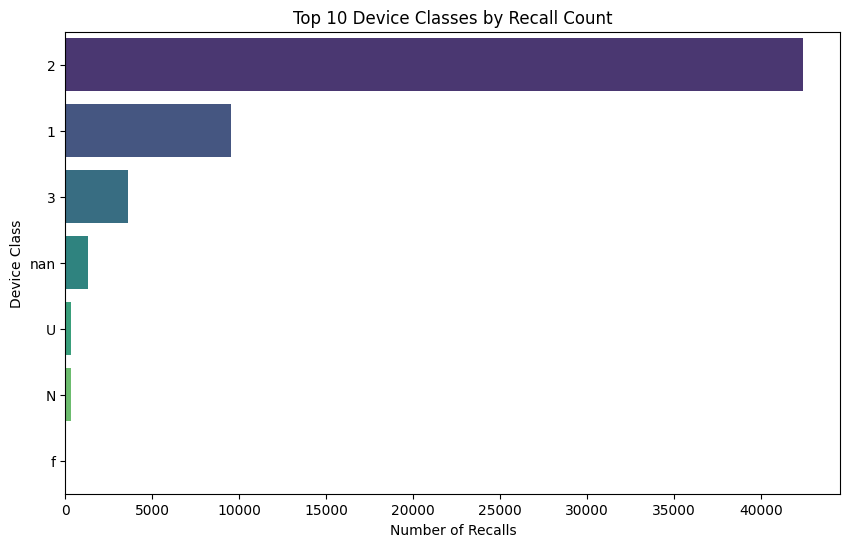

In [43]:
# top 10 device classes

device_class_counts = final_df['device_class'].value_counts().head(10)

# Bar plot
plt.figure(figsize=(10,6))
sns.barplot(x=device_class_counts.values, 
            y=device_class_counts.index, palette='viridis')
plt.title("Top 10 Device Classes by Recall Count")
plt.xlabel("Number of Recalls")
plt.ylabel("Device Class")
plt.show()

In [44]:
print(final_df.columns)

Index(['cfres_id', 'product_code', 'product_description', 'reason_for_recall',
       'device_name', 'device_class', 'event_date_initiated', 'recall_status',
       'similarity_score', 'FDA_CODE', 'problem_term', 'NCIT_CODE',
       'IMDRF_CODE'],
      dtype='object')


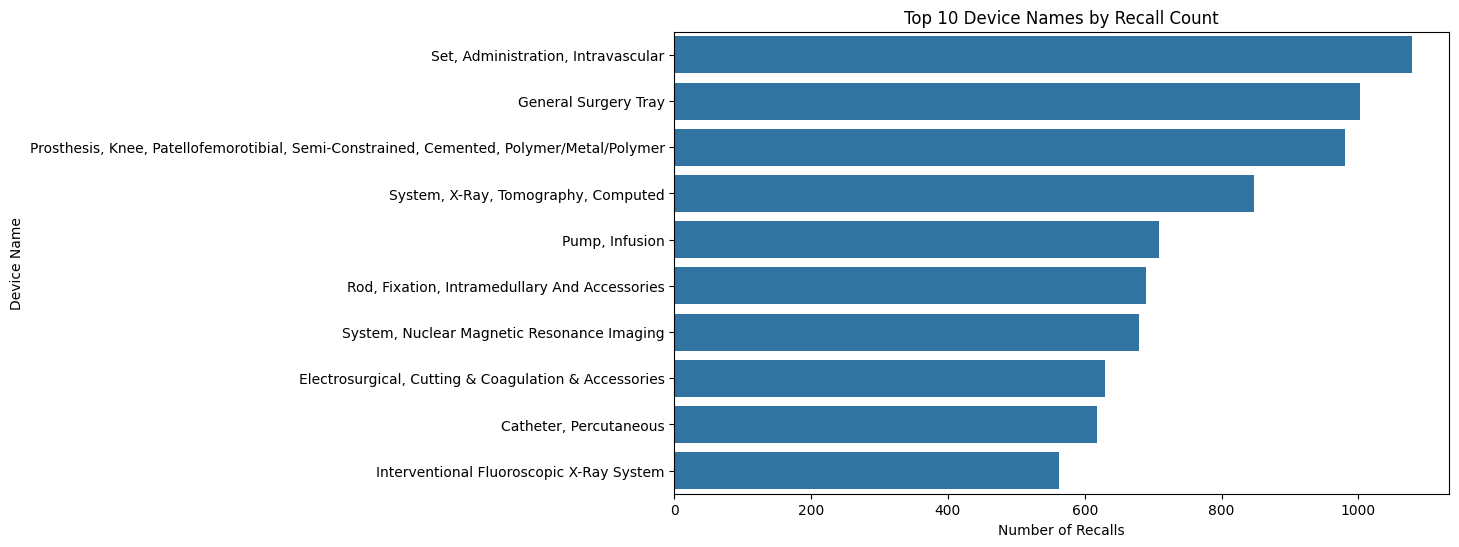

In [45]:
device_name_counts = final_df['device_name'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=device_name_counts.values,
            y=device_name_counts.index)
plt.title("Top 10 Device Names by Recall Count")
plt.xlabel("Number of Recalls")
plt.ylabel("Device Name")
plt.show()

In [46]:
final_df['device_class'].unique()

array(['2', 'nan', 'N', '3', 'f', '1', 'U'], dtype=object)

In [47]:
final_df[final_df['device_class'].isin(['N', 'f', 'U'])]

,cfres_id,product_code,product_description,reason_for_recall,device_name,device_class,event_date_initiated,recall_status,similarity_score,FDA_CODE,problem_term,NCIT_CODE,IMDRF_CODE
3,105700,RER,Raymond Laser alignment guide - Model #1096597...,raymond shipped a laser alignment guide as an ...,Alignment Laser Product,N,2011-11-28,Terminated,0.102701,None,NaN,NaN,NaN
26,214301,RCE,Ami HTX.,the x-ray safety and manufacturing date labels...,"Cabinet X-Ray, Industrial",N,2025-05-13,"Open, Classified",0.101598,None,NaN,NaN,NaN
27,208478,REM,HORIBA custom configured fluorescence instrume...,horiba custom configured fluorescence instrume...,Spectroscopy Instrument,N,2024-03-28,"Open, Classified",0.160977,None,NaN,NaN,NaN
28,196079,RHP,The product is a handheld ultraviolet-C germic...,excessive ultraviolet-c radiation,"Uv Lamp, Germicidal",N,2022-01-27,"Open, Classified",0.367527,1357,radiation leak,C62857,A050404
58,173299,RET,TASE 500 Imaging systems,the nominal ocular hazard distance (nohd) asso...,Laser Target Designator,N,2019-01-29,"Open, Classified",0.119386,None,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
57303,211624,LFL,Brand Name: Olympus Thunderbeat Front-Actuated...,the probe tips of the hand instruments are bei...,"Instrument, Ultrasonic Surgical",U,2024-11-25,"Open, Classified",0.269878,1493,probe failure,NaN,NaN
57306,211621,LFL,Brand Name: Olympus Thunderbeat Front-Actuated...,the probe tips of the hand instruments are bei...,"Instrument, Ultrasonic Surgical",U,2024-11-25,"Open, Classified",0.269878,1493,probe failure,NaN,NaN
57311,213949,QKP,Brand Name: Pluslife SARS-CoV-2 Card\nProduct ...,devices were distributed in the u.s. market wi...,Coronavirus Antigen Detection Test System.,N,2025-01-24,"Open, Classified",0.000000,None,NaN,NaN,NaN
57374,215517,FRO,Brand Name: MediHoney\nProduct Name: MediHoney...,packaging failures were identified which could...,"Dressing, Wound, Drug",U,2025-08-05,"Open, Classified",0.196630,None,NaN,NaN,NaN


In [48]:
final_df[final_df['device_class'].isin(['f','U','N'])][
    ['device_class','device_name','product_description']
].head(20)

,device_class,device_name,product_description
3,N,Alignment Laser Product,Raymond Laser alignment guide - Model #1096597...
26,N,"Cabinet X-Ray, Industrial",Ami HTX.
27,N,Spectroscopy Instrument,HORIBA custom configured fluorescence instrume...
28,N,"Uv Lamp, Germicidal",The product is a handheld ultraviolet-C germic...
58,N,Laser Target Designator,TASE 500 Imaging systems
59,N,High-Power Laser Light Show Projector,ClubMax Laser Projection Series
61,N,"Laser Rangefinders, Time-Of-Flight Speed Measu...",Virus Counter Platform with Model Name VC3100
68,N,"Cabinet X-Ray, Industrial",Nikon Metrology XTH cabinet x-ray Systems whic...
89,f,Pulmonic Valved Conduit,Shelhigh No-React Pulmonic Valve Conduit. **...
92,N,Product Incorporating Certified Class 1 Data U...,"Yamaha Surface Mounter YR series, YS series, i..."


In [49]:
final_df['device_class'] = final_df['device_class'].replace(
    {'U':'Unknown', 'N':'Unknown', 'f':'Unknown'}
)

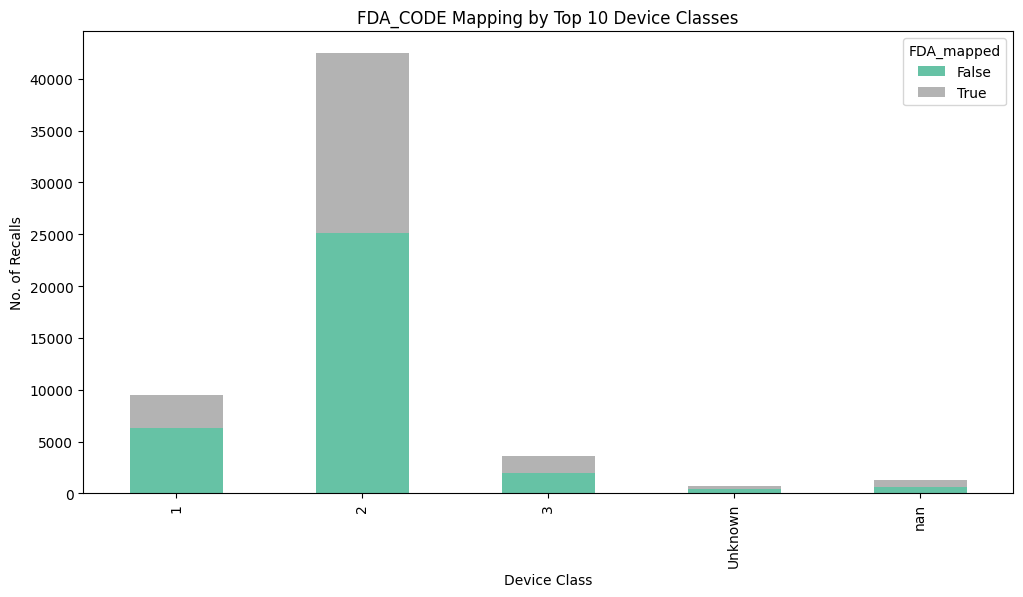

In [50]:
#checks which devices tend to have the most recalls 

final_df['FDA_mapped'] = final_df['FDA_CODE'].notna() #checking cosine similarity 
fda_counts = final_df.groupby(['device_class', 'FDA_mapped']).size().unstack(fill_value=0)

fda_counts.plot(kind='bar', stacked=True, figsize=(12,6), colormap='Set2')
plt.title("FDA_CODE Mapping by Top 10 Device Classes")
plt.ylabel("No. of Recalls")
plt.xlabel("Device Class")
plt.show()

#device 1 harder to map, vague problem descriptions perhaps? 

In [51]:
final_df.sample(50)

,cfres_id,product_code,product_description,reason_for_recall,device_name,device_class,event_date_initiated,recall_status,similarity_score,FDA_CODE,problem_term,NCIT_CODE,IMDRF_CODE,FDA_mapped
43328,143928,DWC,Stockert Heater-Cooler 3T; Item Number 16-02-8...,"on august 15, 2012, sorin informed consignees ...","Controller, Temperature, Cardiopulmonary Bypass",2,2012-08-15,Terminated,0.141818,None,NaN,NaN,NaN,False
10833,147818,DOP,AB SCIEX QTRAP 4500MD LC/MS/MS System\nMass Sp...,multiquant md software where under certain con...,"Mass Spectrometer, Clinical Use",1,2016-06-16,Terminated,0.129651,None,NaN,NaN,NaN,False
36749,43667,CAC,Haemonetics Cell Saver 5+ Autogolous Blood Rec...,device emits radiofrequency which exceed the i...,"Apparatus, Autotransfusion",2,2005-12-21,Terminated,0.322232,1425,device emits odor,C63004,A0301,True
46427,34884,JAA,Siregraph CF X-Ray System. Fluoroscopic image ...,x-ray tube movement when table is tilted more ...,"System, X-Ray, Fluoroscopic, Image-Intensified",2,2004-06-07,Terminated,0.243749,None,NaN,NaN,NaN,False
52058,95527,DQO,"Custom Kit, Sterile EO, Rx Only, Catalog No. K...",defective custom kits may draw in air during u...,"Catheter, Intravascular, Diagnostic",2,2010-10-25,Terminated,0.314162,2298,"valve(s), defective",NaN,NaN,True
31777,152691,LRO,"Regard, Item Number: 880331001, Sterile, OR076...","custom procedure trays contain a component, a ...",General Surgery Tray,2,2017-01-09,Terminated,0.320482,2972,light interference,NaN,NaN,True
18772,126150,KOD,"JMS, Japan, 3 WAY, 20 FR 10 mL \n\nProduct Usa...",the lumen of the medline sterile foley cathete...,"Catheter, Urological",2,2014-02-07,Terminated,0.284912,2888,blocked connection,C63288,A1201,True
15885,190187,CBK,"Puritan Bennett 980 Series Ventilator, 980X1EN...",manufacturing assembly error where a capacitor...,"Ventilator, Continuous, Facility Use",2,2021-11-04,Terminated,0.444955,1663,device inoperable,NaN,NaN,True
56743,200735,BTR,Flexi-Set Cuffed Endotracheal Tube and Stylet ...,reports of disconnection of the 15mm connector...,"Tube, Tracheal (W/Wo Connector)",2,2023-05-25,"Open, Classified",0.344462,2299,"tube(s), defective",NaN,NaN,True
31733,152317,BWN,"STANDARD CRANIOTOME, BLACK MAX",supplied directions for use (dfu) did not cont...,"Table And Attachments, Operating-Room",1,2016-10-06,Terminated,0.259866,1563,failure to service,NaN,NaN,True


In [52]:
final_df[final_df['device_name'].str.contains('set', case=False, na=False)]

,cfres_id,product_code,product_description,reason_for_recall,device_name,device_class,event_date_initiated,recall_status,similarity_score,FDA_CODE,problem_term,NCIT_CODE,IMDRF_CODE,FDA_mapped
197,102086,FPA,Baxter Interlink System Non-DEHP I.V. Catheter...,some of the individual extension set packages ...,"Set, Administration, Intravascular",2,2011-07-06,Terminated,0.213741,None,NaN,NaN,NaN,False
357,115553,FPA,CareFusion SmartSite Gravity Blood Set Model 4...,carefusion is recalling the smartsite gravity ...,"Set, Administration, Intravascular",2,2012-12-20,Terminated,0.364267,2547,separation failure,C63159,A150301,True
385,99076,LHI,"ExactaMix EVA Container, 250mL, REF: 737, Ste...","tpn bags may leak during filling operation, du...","Set, I.V. Fluid Transfer",2,2011-03-08,Terminated,0.359317,1233,filling problem,C63144,A1403,True
386,99078,LHI,"ExactaMix EVA Container, 1000mL, REF: 739, St...","tpn bags may leak during filling operation, du...","Set, I.V. Fluid Transfer",2,2011-03-08,Terminated,0.359317,1233,filling problem,C63144,A1403,True
632,108838,FPA,Medrad(R) Continuum MR Infusion System Primary...,bayer healthcare is recalling all medrad(r) co...,"Set, Administration, Intravascular",2,2012-04-18,Terminated,0.152394,None,NaN,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57455,216937,FPA,IV Administration Set utilized in gravity IV a...,potential for backflow of medication from seco...,"Set, Administration, Intravascular",2,2025-10-29,"Open, Classified",0.273669,1064,backflow,C63290,A140501,True
57456,216923,FPA,IV Administration Set utilized in gravity IV a...,potential for backflow of medication from seco...,"Set, Administration, Intravascular",2,2025-10-29,"Open, Classified",0.273669,1064,backflow,C63290,A140501,True
57457,216808,FPA,Blood Administration Set utilized in gravity I...,potential for backflow of medication from seco...,"Set, Administration, Intravascular",2,2025-10-29,"Open, Classified",0.273669,1064,backflow,C63290,A140501,True
57458,216821,FPA,Extension Set utilized in gravity IV administr...,potential for backflow of medication from seco...,"Set, Administration, Intravascular",2,2025-10-29,"Open, Classified",0.273669,1064,backflow,C63290,A140501,True


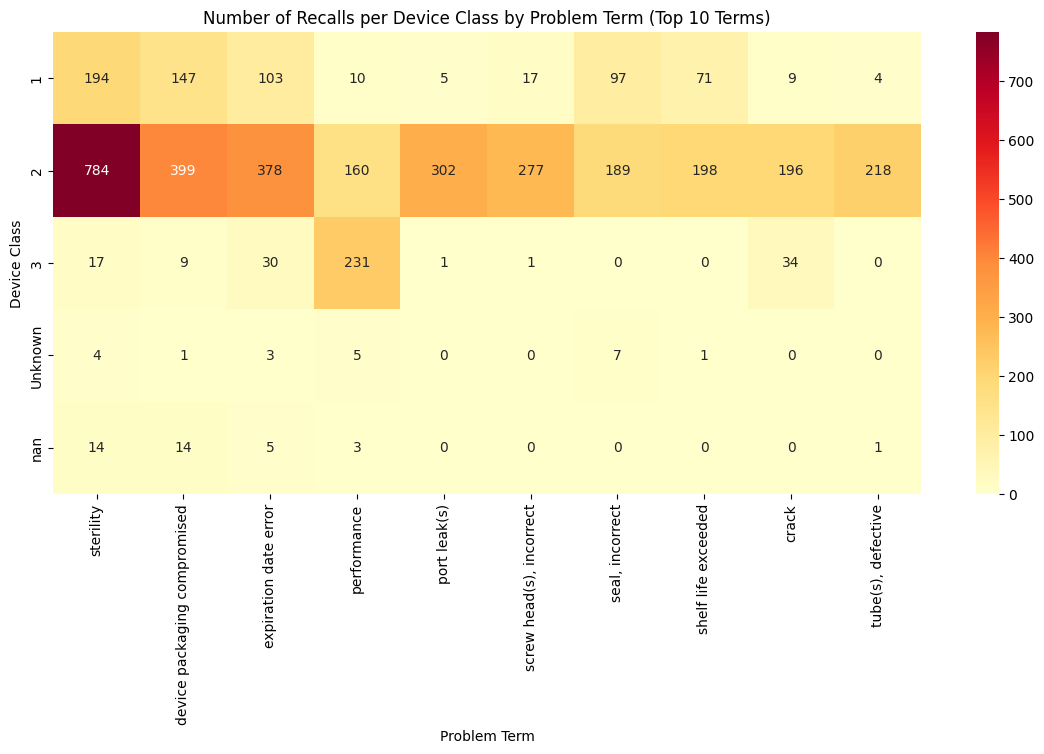

In [53]:
heatmap_data = final_df.pivot_table(
    index='device_class',
    columns='problem_term',
    values='cfres_id',  # using cfres_id just as a count
    aggfunc='count',
    fill_value=0
)

top_terms = heatmap_data.sum().sort_values(ascending=False).head(10).index
heatmap_data = heatmap_data[top_terms]

plt.figure(figsize=(14,6))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlOrRd")
plt.title("Number of Recalls per Device Class by Problem Term (Top 10 Terms)")
plt.ylabel("Device Class")
plt.xlabel("Problem Term")
plt.show()

In [59]:
term_counts = final_df['problem_term'].value_counts()

# View top 20 most common terms
top_20_terms = term_counts.head(20)

print(top_20_terms)

problem_term
sterility                       1013
device packaging compromised     570
expiration date error            519
performance                      409
port leak(s)                     308
screw head(s), incorrect         295
seal, incorrect                  293
shelf life exceeded              270
crack                            239
tube(s), defective               223
off-label use                    222
blood in tubing                  222
failure to cycle                 216
false negative result            215
reservoir                        214
air leak                         201
inadequate storage               200
moisture damage                  199
break                            191
no pressure                      181
Name: count, dtype: int64


In [60]:
problem_stats = final_df['problem_term'].describe()
print(problem_stats)

count         23049
unique          690
top       sterility
freq           1013
Name: problem_term, dtype: object


In [54]:
final_df.to_csv("problem_recall_dataset.csv", index=False)